# Uncertainty prediction

In [ ]:
import time
import sys

import numpy as np
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from scipy.stats import norm

## Loading and preprocessing the data

In [ ]:
spectra = np.load(f"../datasets/galah/spectra.npy")
spectra_length = spectra.shape[1]

# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
units = ["M_sun", "Gyr", "L_sun", "pc", "K", "", "", ""]
labels = np.load(f"../datasets/galah/labels.npy")

# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
units = units[-4:-1]

# Get the number of labels and samples
n_labels = labels.shape[1]
n_samples = spectra.shape[0]

In [55]:
print("spectra shape:", spectra.shape)
print("labels shape:", labels.shape)
print("label names:", labelNames)

spectra shape: (8914, 16384)
labels shape: (8914, 3)
label names: ['t_eff', 'log_g', 'fe_h']


In [56]:
print("spectra length:", spectra_length)
print("number of samples:", n_samples)
print("number of labels:", n_labels)

spectra length: 16384
number of samples: 8914
number of labels: 3


In [ ]:
# normalize the spectra
spectra_scaled = np.log(np.maximum(spectra, 0.2))

## Training the neural network

In [58]:
# Check for available devices and select if available
device = (
    "cuda"
    if torch.cuda.is_available()  # CUDA GPU
    else "mps"
    if torch.backends.mps.is_available()  # Apple Metal Performance Shaders
    else "xpu"
    if torch.xpu.is_available()  # Intel XPU
    else "cpu"  # Fallback to CPU if neither CUDA nor MPS are found
)
print(f"Using device: {device}")

Using device: xpu


In [59]:
# Hyperparameters
learning_rate = 1e-4
batch_size = 32
num_epochs = 50
patience = 10 # Training loop with early stopping, if the validation loss does not improve for 'patience' epochs
train_fraction = 0.7
val_fraction = 0.15

In [60]:
# Split data into train, validation, and test sets
r1 = 1 - train_fraction
r2 = val_fraction / r1

X_train, X_temp, labels_train, labels_temp = train_test_split(spectra_scaled, labels, test_size=r1, random_state=25)
X_val, X_test, labels_val, labels_test = train_test_split(X_temp, labels_temp, test_size=r2, random_state=37)

In [61]:
# Normalize the labels using only the training set statistics
scaler = StandardScaler()
y_train = scaler.fit_transform(labels_train)
y_val = scaler.transform(labels_val)
y_test = scaler.transform(labels_test)

In [ ]:
# Define a custom Dataset class
class CustomDataset(TensorDataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets with torch tensors
train_dataset = CustomDataset(torch.as_tensor(X_train, dtype=torch.float32).view(-1, 1, spectra_length),
                              torch.as_tensor(y_train, dtype=torch.float32).view(-1, n_labels))
val_dataset = CustomDataset(torch.as_tensor(X_val, dtype=torch.float32).view(-1, 1, spectra_length),
                            torch.as_tensor(y_val, dtype=torch.float32).view(-1, n_labels))
test_dataset = CustomDataset(torch.as_tensor(X_test, dtype=torch.float32).view(-1, 1, spectra_length),
                             torch.as_tensor(y_test, dtype=torch.float32).view(-1, n_labels))

In [63]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [64]:
class GalahCNN(nn.Module):
    def __init__(self):
        super(GalahCNN, self).__init__()
        
        # Feature extraction (3 convolutional layers)
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, padding=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # Linear regression (2 fully connected layers)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * spectra_length // 8, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Avoid overfitting
            nn.Linear(256, 2*n_labels) # Output: Teff, logg, [Fe/H] AND UNCERTAINTIES
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

In [65]:
class TinyCNN(nn.Module):
	def __init__(self):
		super(TinyCNN, self).__init__()

		self.model = nn.Sequential(
			nn.Conv1d(1, 10, kernel_size=5),
			nn.ReLU(),
			nn.BatchNorm1d(10),
			nn.Dropout(0.1),
			nn.AvgPool1d(3),

			nn.Conv1d(10, 20, kernel_size=5),
			nn.ReLU(),
			nn.BatchNorm1d(20),
			nn.Dropout(0.1),
			nn.AvgPool1d(3),

			nn.Conv1d(20, 40, kernel_size=5),
			nn.ReLU(),
			nn.BatchNorm1d(40),
			nn.Dropout(0.1),
			nn.AvgPool1d(3),

			nn.Conv1d(40, 10, kernel_size=1),
			nn.ReLU(),
			nn.BatchNorm1d(10),
			nn.Dropout(0.1),
			nn.AvgPool1d(2),

			nn.Conv1d(10, 12, kernel_size=3),
			nn.ReLU(),
			nn.BatchNorm1d(12),
			nn.Dropout(0.2),

			nn.Conv1d(12, 10, kernel_size=1),
			nn.Dropout(0.2),

			nn.Linear(300, 32), # batch, filters, * -> batch, filters, 32
			nn.ReLU(),
			nn.Flatten(),
			nn.Linear(10*32, 128),
			nn.ReLU(),
			nn.Linear(128, 2*n_labels)
		)

	def forward(self, x):
		x = self.model(x)
		return x

In [66]:
# Negative log-likelihood loss function for regression with uncertainty estimation
def nll_loss(preds, targets):
    # Split predictions into mean and log variance
    mean = preds[:, :n_labels]
    log_std = preds[:, n_labels:]
    
    # Calculate the negative log-likelihood loss
    std = torch.exp(log_std)
    nll = torch.mean(0.5 * (targets - mean) ** 2 / (std ** 2) + log_std)
    
    return nll

In [67]:
# Initialize the model
model = GalahCNN().to(device)
loss_fn = nll_loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [68]:
# Print the model summary before moving it to the device
summary(model);

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv1d: 2-1                       192
|    └─ReLU: 2-2                         --
|    └─MaxPool1d: 2-3                    --
|    └─Conv1d: 2-4                       3,616
|    └─ReLU: 2-5                         --
|    └─MaxPool1d: 2-6                    --
|    └─Conv1d: 2-7                       10,304
|    └─ReLU: 2-8                         --
|    └─MaxPool1d: 2-9                    --
├─Sequential: 1-2                        --
|    └─Flatten: 2-10                     --
|    └─Linear: 2-11                      33,554,688
|    └─ReLU: 2-12                        --
|    └─Dropout: 2-13                     --
|    └─Linear: 2-14                      1,542
Total params: 33,570,342
Trainable params: 33,570,342
Non-trainable params: 0


In [69]:
train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(num_epochs):  # loop through every epoch
    start_time = time.time()  # Start the timer for this epoch
    # Training
    model.train()  # The model should be in training mode to use batch normalization and dropout
    train_loss = 0

    # loop through every batch
    for step, (batch_x, batch_y) in enumerate(train_loader):
        # move the batch to the same device as the model
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # set the gradients to zero
        optimizer.zero_grad()

        # make a prediction with the current model
        predictions = model(batch_x)

        # calculate the loss based on the prediction
        loss = loss_fn(predictions, batch_y)

        # calculated the gradients for the given loss
        loss.backward()

        # updates the weights and biases for the given gradients
        optimizer.step()

        # calculate loss per batch
        train_loss += loss.item()

        # Print progress every 10th step, updating the same line
        if (step + 1) % 10 == 0:
            sys.stdout.write(f"\rEpoch [{epoch + 1}/{num_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
            sys.stdout.flush()

    # calculate loss per epoch
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    # The model should be in eval mode to not use batch normalization and dropout
    model.eval()
    val_loss = 0

    # make sure the gradients are not changed in this step
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # move the batch to the same device as the model
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            # make a prediction with the current model
            predictions = model(batch_x)

            # calculate the loss based on the prediction
            loss = loss_fn(predictions, batch_y)

            # calculate loss per batch
            val_loss += loss.item()

    # calulate loss per epoch
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # Print epoch summary
    epoch_time = time.time() - start_time  # Calculate epoch time
    sys.stdout.write(f"\rEpoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Time: {epoch_time:.2f} seconds\n")
    sys.stdout.flush()

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("\nEarly stopping triggered.")
            break


Epoch [1/50], Train Loss: 0.2739, Val Loss: -0.0917, Time: 16.07 seconds
Epoch [2/50], Train Loss: -0.2453, Val Loss: -0.4764, Time: 14.20 seconds
Epoch [3/50], Train Loss: -0.4799, Val Loss: -0.6018, Time: 14.56 seconds
Epoch [4/50], Train Loss: -0.6070, Val Loss: -0.8132, Time: 14.54 seconds
Epoch [5/50], Train Loss: -0.6855, Val Loss: -0.8683, Time: 14.57 seconds
Epoch [6/50], Train Loss: -0.7702, Val Loss: -0.9547, Time: 14.63 seconds
Epoch [7/50], Train Loss: -0.8070, Val Loss: -1.0885, Time: 14.79 seconds
Epoch [8/50], Train Loss: -0.8438, Val Loss: -1.0680, Time: 14.57 seconds
Epoch [9/50], Train Loss: -0.8543, Val Loss: -1.0626, Time: 14.63 seconds
Epoch [10/50], Train Loss: -0.8782, Val Loss: -1.1213, Time: 14.29 seconds
Epoch [11/50], Train Loss: -0.9042, Val Loss: -1.1050, Time: 13.08 seconds
Epoch [12/50], Train Loss: -0.9213, Val Loss: -1.1442, Time: 12.98 seconds
Epoch [13/50], Train Loss: -0.9519, Val Loss: -1.0821, Time: 12.81 seconds
Epoch [14/50], Train Loss: -0.9538,

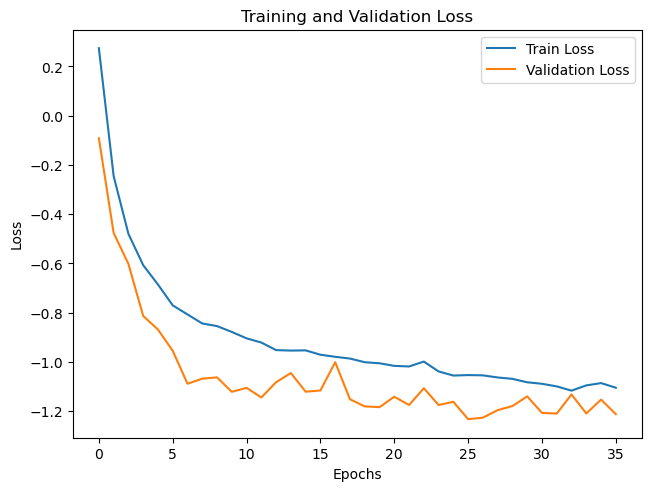

In [70]:
# Plot training/validation loss
fig, ax = plt.subplots(layout="constrained")

ax.plot(train_losses, label="Train Loss")
ax.plot(val_losses, label="Validation Loss")

ax.legend()
ax.set(
    xlabel="Epochs",
    ylabel="Loss",
    title="Training and Validation Loss",
);

## Evaluating the model

In [71]:
# Test the model
model.eval()
test_loss = 0
y_test_pred = np.array([])

# make sure the gradients are not changed in this step
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        # move the batch to the same device as the model
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # make a prediction with the current model
        predictions = model(batch_x)
        y_test_pred = np.append(y_test_pred, predictions.cpu().numpy())

        # calculate the loss based on the prediction
        loss = loss_fn(predictions, batch_y)

        # calulate loss per batch
        test_loss += loss.item()

test_loss /= len(test_loader)  # calculate total loss
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Final Train Loss: -1.1046
Final Validation Loss: -1.2120
Final Test Loss: -1.1912


## Evaluating the results

In [72]:
y_test_pred = y_test_pred.reshape(-1, 2, n_labels)

labels_test_pred = scaler.inverse_transform(y_test_pred[:, 0, :])
uncertainties_test = scaler.scale_ * np.exp(y_test_pred[:, 1, :])

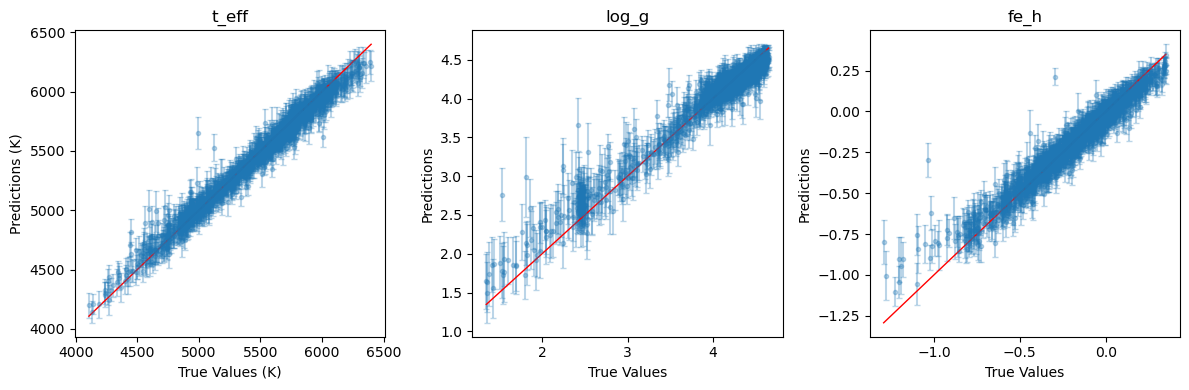

In [73]:
plt.figure(figsize=(12, 4))
for i in range(n_labels):
    plt.subplot(1, n_labels, i+1)
    # plt.scatter(labels_test[:, i], labels_test_pred[:, i], label=labels[i], alpha=0.5, s=3)
    plt.errorbar(labels_test[:, i], labels_test_pred[:, i], yerr=uncertainties_test[:, i],
                 fmt='o', markersize=3, capsize=2, alpha=0.3)
    plt.plot([labels_test[:, i].min(), labels_test[:, i].max()], 
             [labels_test[:, i].min(), labels_test[:, i].max()], 'r', lw=1) # Add a y=x line for reference
    plt.xlabel("True Values")
    plt.ylabel("Predictions")
    if units[i]:
        plt.xlabel(f"True Values ({units[i]})")
        plt.ylabel(f"Predictions ({units[i]})")
    plt.title(labelNames[i])
plt.tight_layout()
plt.show()

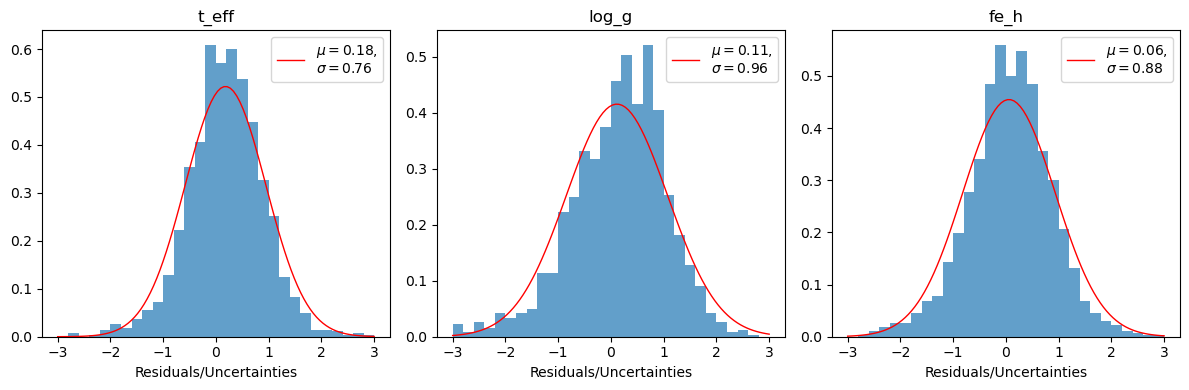

In [ ]:
residuals = (labels_test - labels_test_pred) / uncertainties_test
t = np.linspace(-3, 3, 100)

plt.figure(figsize=(12, 4))
for i in range(n_labels):
    plt.subplot(1, n_labels, i+1)
    mu_fit = np.mean(residuals[:, i])
    std_fit = np.std(residuals[:, i])
    plt.hist(residuals[:, i], range=[-3, 3], bins=30, alpha=0.7, density=True)
    plt.plot(t, norm.pdf(t, mu_fit, std_fit), color='r', linewidth=1,
             label=rf'$\mu={mu_fit:.2f}$,{'\n'}$\sigma={std_fit:.2f}$')
    plt.legend()
    plt.xlabel("Residuals/Uncertainties")
    plt.title(labelNames[i])
plt.tight_layout()
plt.show()